In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

from scipy import stats

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import sys
print(sys.executable)

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [9]:
# ============================================
# Load California Housing Dataset
# ============================================

try:

  url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"

  df = pd.read_csv(url)
  print("Dataset loaded successfully from URL!")

except:

    print("URL download failed.")
    print("Generating synthetic dataset...")

np.random.seed(42)

n_samples = 5000

df = pd.DataFrame({
"longitude": np.random.uniform(-124.5, -114.5, n_samples),

"latitude": np.random.uniform(32.5, 42.0, n_samples),

"housing_median_age":
np.random.randint(1, 52, n_samples),

"total_rooms":
np.random.normal(2000, 1000, n_samples).astype(int),
"total_bedrooms":
np.random.normal(500, 250, n_samples).astype(int),

"population":
np.random.normal(1200, 800, n_samples).astype(int),

"households":
np.random.normal(450, 250, n_samples).astype(int),

"median_income":
np.random.uniform(0.5, 15, n_samples),

"median_house_value":
np.random.normal(200000, 80000, n_samples).astype(int),

"ocean_proximity":
np.random.choice(
[
"NEAR BAY",
"<1H OCEAN",
"INLAND",
"NEAR OCEAN",
"ISLAND"
],
n_samples,
p=[0.30, 0.30, 0.30, 0.09, 0.01]
)

})

# Create a relationship between features and house price
df["median_house_value"] = (

df["median_income"] * 40000 +

df["housing_median_age"] * 1000 +
df["total_rooms"] * 20 +

np.random.normal(0, 30000, n_samples)

).astype(int)

# Limit house values to realistic values
df["median_house_value"] = df["median_house_value"].clip(
lower=50000,
upper=500001
)

print("Synthetic dataset created successfully!")
print(f"Dataset Shape: {df.shape}")

Dataset loaded successfully from URL!
Synthetic dataset created successfully!
Dataset Shape: (5000, 10)


In [19]:
print("First Five Rows:")
df.head()

First Five Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-120.754599,36.239537,32,2364,433,1213,91,2.791103,175259,NEAR BAY
1,-114.992857,36.997639,36,1872,59,1169,367,8.437746,467922,INLAND
2,-117.180061,40.618200,50,2373,538,476,916,9.032428,415249,INLAND
3,-118.513415,35.730042,37,3874,496,1757,194,10.763908,500001,<1H OCEAN
4,-122.939814,40.761672,48,762,530,1447,594,9.256520,400218,<1H OCEAN


In [ ]:
print("Dataset Information")
print("-" * 50)
df.info()

In [ ]:
print("Statistical Summary")
print("-" * 50)
df.describe()

In [ ]:
print("Missing Values")
print("-" * 50)
print(df.isnull().sum())

In [ ]:
if df.isnull().sum().sum() > 0:
    print("Removing rows with missing values...")
df = df.dropna()
print(f"New Dataset Shape: {df.shape}")

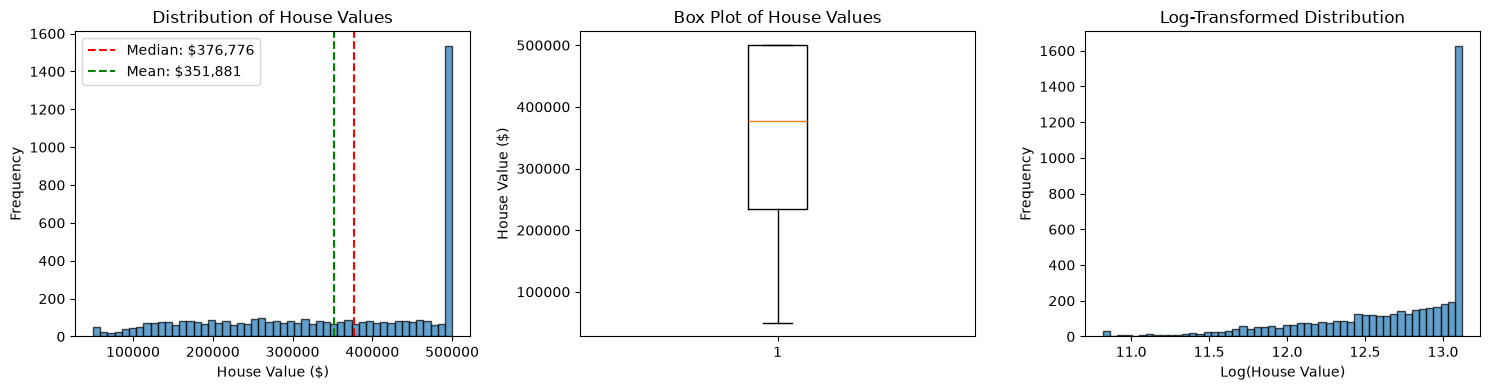

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --------------------------
# Histogram
# --------------------------

axes[0].hist(
df["median_house_value"],
bins=50,
edgecolor="black",
alpha=0.7
)

axes[0].set_title("Distribution of House Values")
axes[0].set_xlabel("House Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
df["median_house_value"].median(),
color="red",
linestyle="--",
label=f"Median: ${df['median_house_value'].median():,.0f}"
)

axes[0].axvline(
df["median_house_value"].mean(),
color="green",
linestyle="--",
label=f"Mean: ${df['median_house_value'].mean():,.0f}"
)

axes[0].legend()

# --------------------------
# Box Plot
# --------------------------

axes[1].boxplot(df["median_house_value"])

axes[1].set_title("Box Plot of House Values")
axes[1].set_ylabel("House Value ($)")

# --------------------------
# Log Transformation
# --------------------------

axes[2].hist(
np.log1p(df["median_house_value"]),
bins=50,
edgecolor="black",
alpha=0.7
)

axes[2].set_title("Log-Transformed Distribution")
axes[2].set_xlabel("Log(House Value)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()

plt.show()

In [ ]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
correlations = (
df[numeric_columns]
.corr()["median_house_value"]
.sort_values(ascending=False)
)
print("Top Correlations with House Price")
print(correlations)

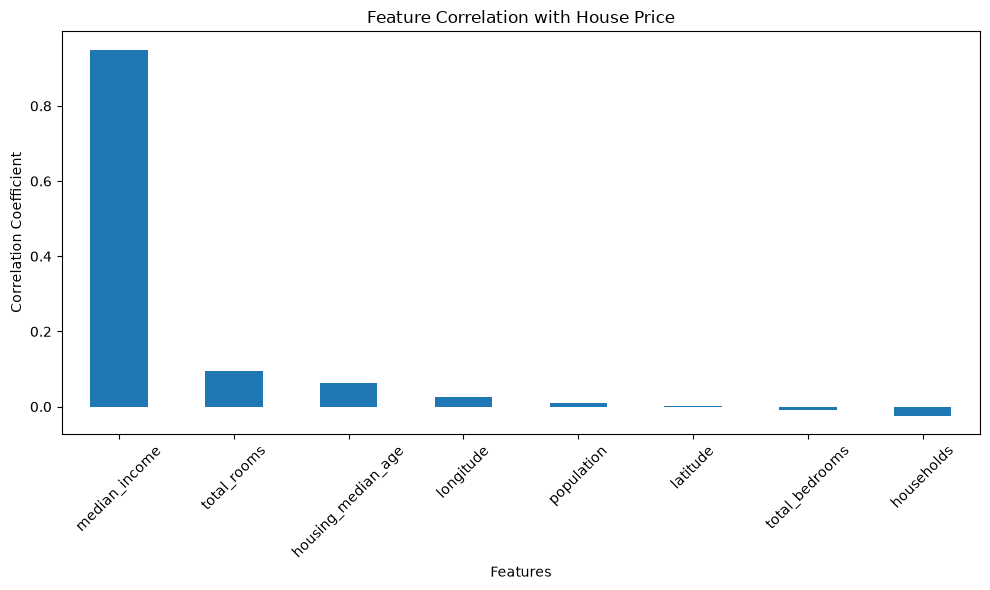

In [20]:
plt.figure(figsize=(10, 6))

correlations.drop("median_house_value").plot(kind="bar")

plt.title("Feature Correlation with House Price")

plt.xlabel("Features")

plt.ylabel("Correlation Coefficient")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

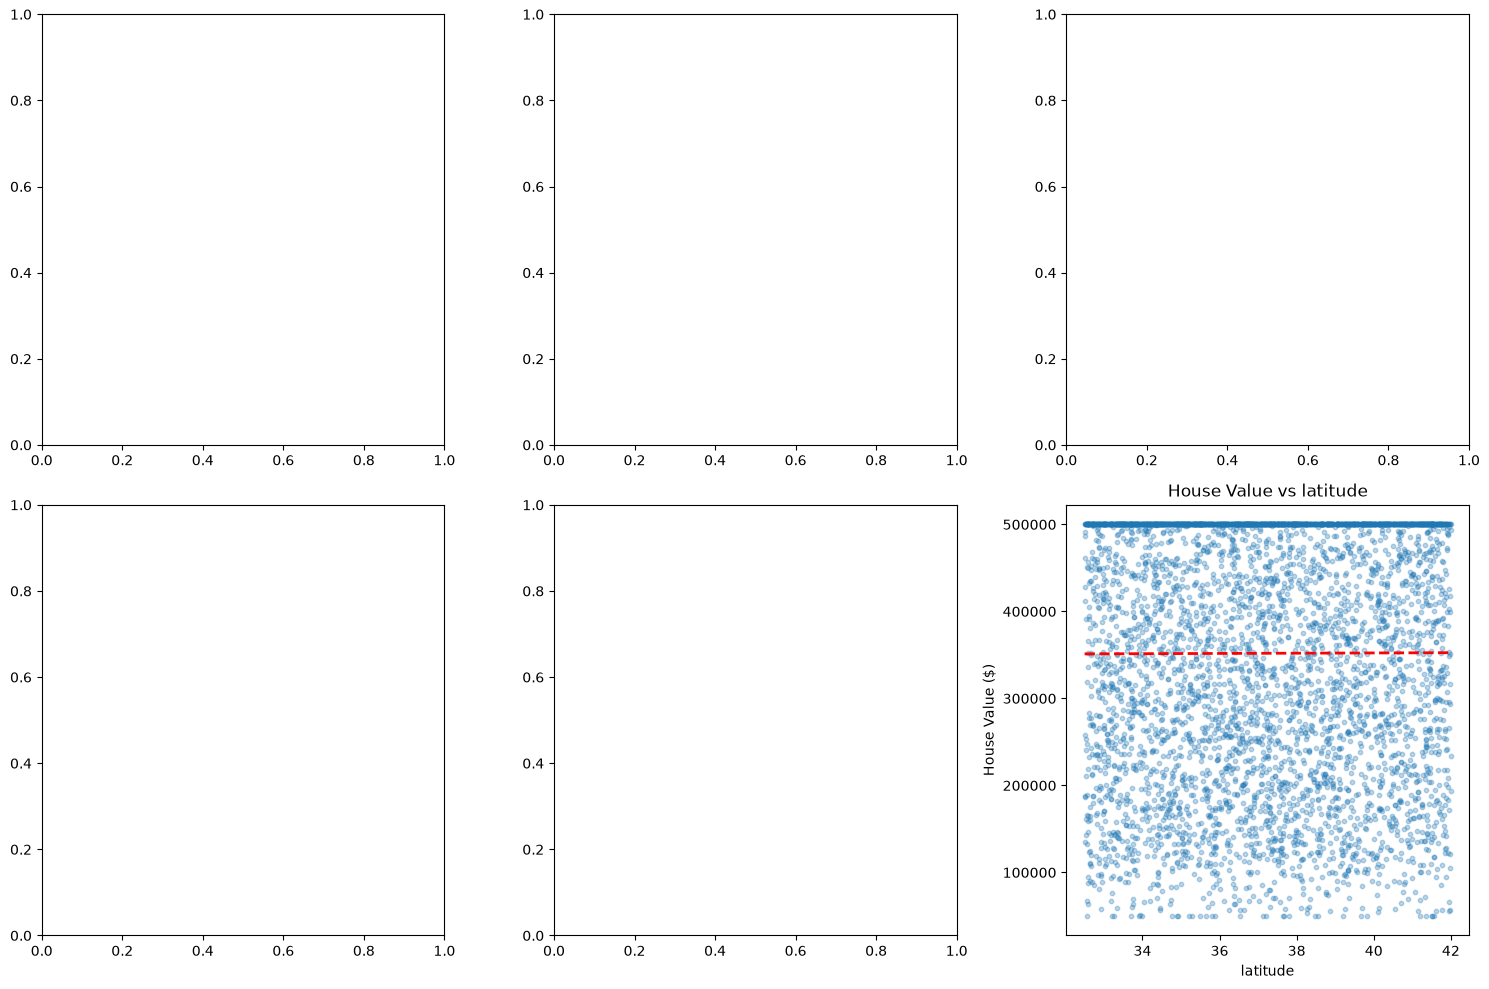

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = [
"median_income",
"housing_median_age",
"total_rooms",
"population",
"households",
"latitude"
]

for index, feature in enumerate(features):

    row = index // 3
    column = index % 3

axes[row, column].scatter(
df[feature],
df["median_house_value"],
alpha=0.3,
s=10
)

axes[row, column].set_title(f"House Value vs {feature}")

axes[row, column].set_xlabel(feature)

axes[row, column].set_ylabel("House Value ($)")
# Add linear trend line
z = np.polyfit(df[feature], df["median_house_value"], 1)

p = np.poly1d(z)
axes[row, column].plot(
df[feature].sort_values(),
p(df[feature].sort_values()),

"r--",
linewidth=2
)

plt.tight_layout()

plt.show()